# Seasonal Agriculture Performance Analysis

### VOIS AICTE Batch 1 | 2026–2027 Major Project

**Domain:** Data Analytics  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy  
**Dataset:** `seasonal_agriculture_performance_dataset.csv`

---

## Problem Statement
Agricultural performance changes with seasonal environmental conditions, farming practices, resource usage, and economic conditions. This project analyzes the agricultural dataset to identify meaningful seasonal differences, relationships, trends, unusual patterns, and evidence-based recommendations.

## Main Objective
To investigate how agricultural performance varies across **Kharif, Rabi, and Zaid** seasons and determine which environmental, resource, operational, and economic factors are associated with those differences.

## Analytical Questions
1. How does agricultural performance vary across seasons?
2. Which environmental conditions change most between seasons?
3. How does crop yield differ across seasons?
4. Are resource usage and water efficiency different between seasons?
5. How do revenue, cost, profit, and profitability vary by season?
6. Are environmental/resource variables related to crop yield?
7. Do irrigation methods differ across seasons?
8. Are seasonal patterns consistent across states?
9. What unusual values or seasonal patterns deserve further investigation?
10. What data-driven recommendations can be made for seasonal planning?

> **Note:** Correlation and statistical tests identify associations/differences in this dataset; they do not by themselves prove causation.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")


## 2. Load the Dataset

In [2]:
from google.colab import files
import io

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Dataset loaded successfully.
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 3. Understand the Dataset

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nUnique values in key categorical columns:")
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique())
    print()


Rows: 4000
Columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Unique values in key categorical columns:
State: 8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District: 10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop: 8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season: 3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method: 4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']



## 4. Data Quality Check

In [4]:
print("Duplicate rows:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("\nMissing values:")
display(missing.to_frame("Missing Count"))

print("\nMissing percentage:")
display((missing / len(df) * 100).round(2).to_frame("Missing %"))


Duplicate rows: 0

Missing values:


,Missing Count
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32



Missing percentage:


,Missing %
Rainfall_mm,1.20
Soil_Moisture_pct,1.00
Yield_Tonnes_Ha,0.80


## 5. Data Cleaning and Preparation

The dataset contains a small number of missing values in **Rainfall**, **Soil Moisture**, and **Yield**.

- Rainfall and soil moisture are filled using the **median of their season**, which preserves seasonal context.
- Yield is not imputed because it is a primary performance outcome. Rows with missing yield are excluded only from yield-specific analysis.
- Duplicate rows are removed if any are found.
- Numeric columns are converted safely to numeric types.


In [5]:
data = df.copy()

# Remove exact duplicate rows
data = data.drop_duplicates().copy()

# Ensure numeric columns are numeric
numeric_cols = data.select_dtypes(include=np.number).columns
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Seasonal median imputation for environmental variables
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    data[col] = data.groupby("Season")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Rows after duplicate removal:", len(data))
print("\nRemaining missing values:")
display(data.isna().sum()[data.isna().sum() > 0].to_frame("Missing Count"))


Rows after duplicate removal: 4000

Remaining missing values:


,Missing Count
Yield_Tonnes_Ha,32


## 6. Descriptive Statistics

In [6]:
display(data.describe().T)

print("\nCategorical summaries:")
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"\n{col}")
    display(data[col].value_counts().to_frame("Count"))


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.71,288.43,80.00,370.43,581.00,836.12,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.50,6.70,8.00,21.70,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00



Categorical summaries:

State


,Count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484



District


,Count
District,
Ludhiana,427
Warangal,422
Nalgonda,415
Erode,403
Rajkot,401
Krishna,393
Indore,392
Guntur,390
Raichur,386


...

,Count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



Season


,Count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Irrigation_Method


,Count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


## 7. Create Useful Performance Metrics

In [7]:
data["Profit_Margin_pct"] = np.where(
    data["Revenue_INR"] != 0,
    data["Profit_INR"] / data["Revenue_INR"] * 100,
    np.nan
)

data["ROI_pct"] = np.where(
    data["Total_Cost_INR"] != 0,
    data["Profit_INR"] / data["Total_Cost_INR"] * 100,
    np.nan
)

data["Production_per_Hectare"] = np.where(
    data["Farm_Area_Hectares"] != 0,
    data["Production_Tonnes"] / data["Farm_Area_Hectares"],
    np.nan
)

metrics = [
    "Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR",
    "Total_Cost_INR", "Profit_INR", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Profit_Margin_pct", "ROI_pct"
]

display(data[metrics].describe().T)


,count,mean,std,min,25%,50%,75%,max
Yield_Tonnes_Ha,"3,968.00",5.27,13.36,0.30,1.05,1.74,2.84,101.44
Production_Tonnes,"4,000.00",43.25,126.88,0.15,5.02,11.77,24.36,"1,424.40"
Revenue_INR,"4,000.00","637,860.05","636,974.71","6,107.00","207,517.25","456,830.50","836,874.75","5,080,900.00"
Total_Cost_INR,"4,000.00","526,303.58","294,419.14","26,826.00","274,577.50","519,082.50","761,996.50","1,349,990.00"
Profit_INR,"4,000.00","111,556.46","545,081.89","-1,019,223.00","-148,731.75","3,673.00","216,187.75","4,345,421.00"
Water_Used_m3,"4,000.00","6,045.57","5,572.94",128.00,"2,268.75","4,435.00","7,829.75","40,902.00"
Water_Efficiency_t_per_1000m3,"4,000.00",5.39,8.84,0.14,1.66,2.94,5.15,79.80
Profit_Margin_pct,"4,000.00",-45.49,158.09,"-1,461.85",-60.19,1.15,32.89,85.92
ROI_pct,"4,000.00",22.56,91.73,-93.60,-37.58,1.16,49.00,610.29


## 8. Overall Seasonal Comparison

In [8]:
season_summary = data.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_T_per_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_T=("Production_Tonnes", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Cost_INR=("Total_Cost_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean"),
    Avg_Profit_Margin_pct=("Profit_Margin_pct", "mean"),
    Avg_ROI_pct=("ROI_pct", "mean")
).round(2)

display(season_summary.sort_values("Avg_Profit_INR", ascending=False))


,Farms,Avg_Yield_T_per_Ha,Avg_Production_T,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Avg_Profit_Margin_pct,Avg_ROI_pct
Season,,,,,,,,,,,
Kharif,1779,5.64,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47,-38.64,35.45
Rabi,1627,5.08,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48,-44.27,17.60
Zaid,594,4.67,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22,-69.35,-2.47


## 9. Seasonal Performance Visualization

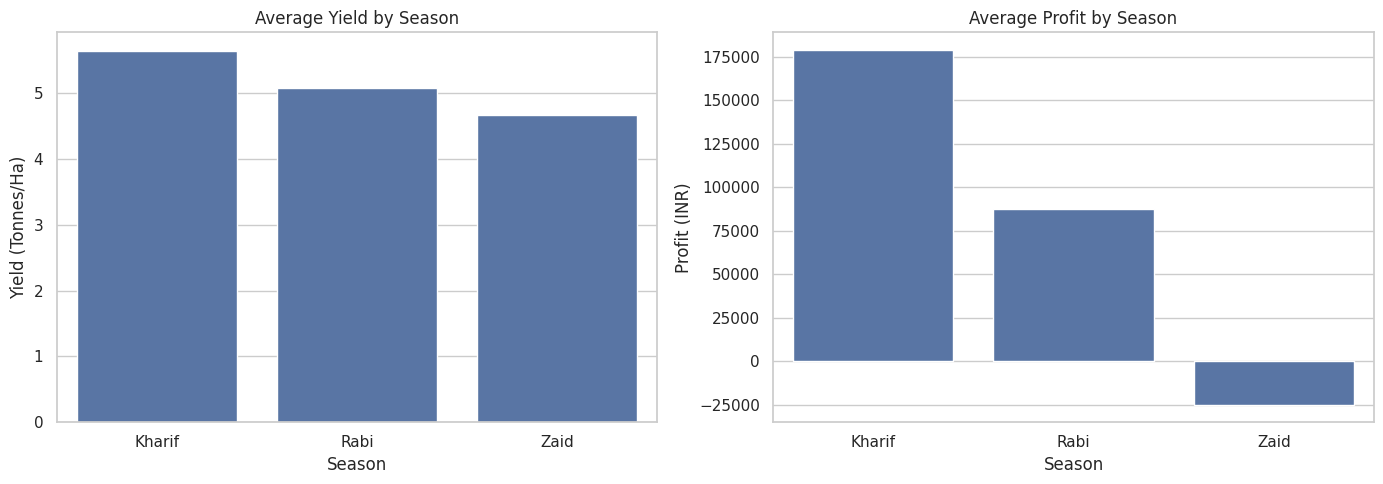

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=data, x="Season", y="Yield_Tonnes_Ha", estimator="mean", errorbar=None, ax=axes[0])
axes[0].set_title("Average Yield by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Yield (Tonnes/Ha)")

sns.barplot(data=data, x="Season", y="Profit_INR", estimator="mean", errorbar=None, ax=axes[1])
axes[1].set_title("Average Profit by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Profit (INR)")

plt.tight_layout()
plt.show()


## 10. Environmental Conditions Across Seasons

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20,6.73
Rabi,435.94,23.49,57.89,7.59,24.05,6.67
Zaid,299.12,31.04,52.01,8.18,19.17,6.69


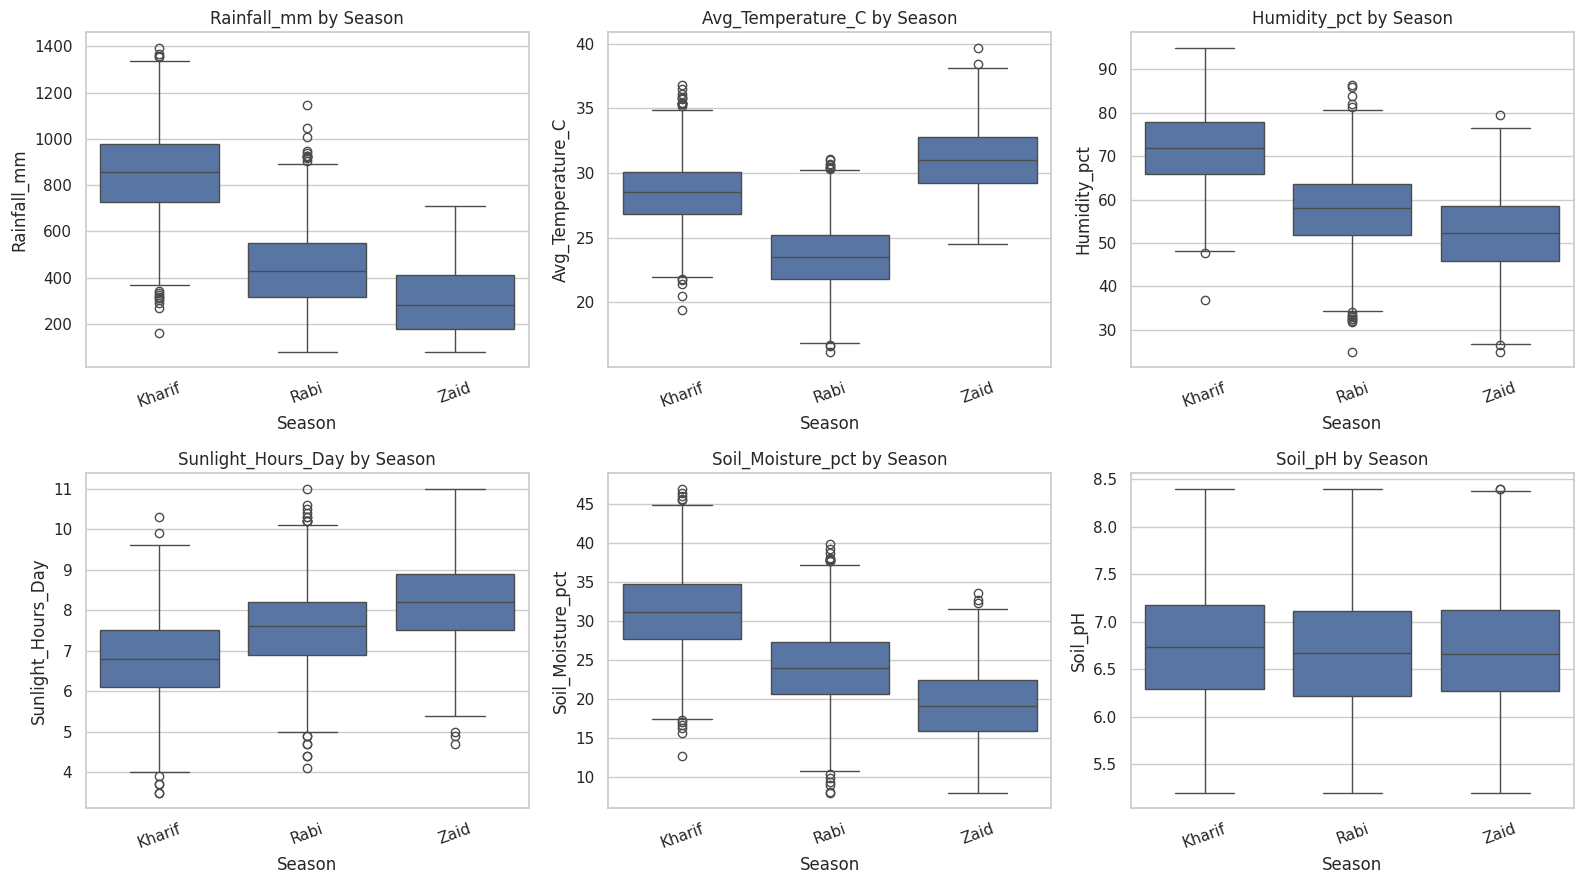

In [10]:
environmental = data.groupby("Season")[
    ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
     "Sunlight_Hours_Day", "Soil_Moisture_pct", "Soil_pH"]
].mean().round(2)

display(environmental)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
        "Sunlight_Hours_Day", "Soil_Moisture_pct", "Soil_pH"]

for ax, col in zip(axes.flat, cols):
    sns.boxplot(data=data, x="Season", y=col, ax=ax)
    ax.set_title(f"{col} by Season")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 11. Resource Usage Across Seasons

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,"6,102.20",5.89
Rabi,120.40,57.31,103.93,185.41,5.02,"5,846.99",5.19
Zaid,120.53,58.13,105.42,184.64,5.17,"6,419.89",4.41


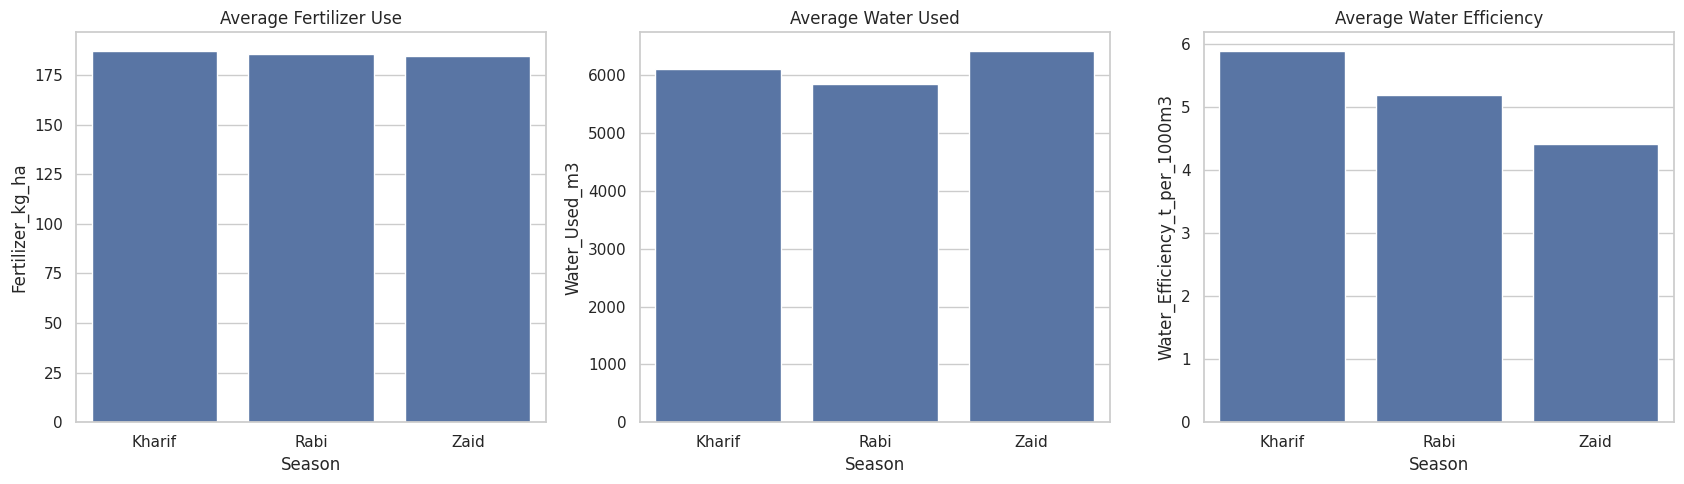

In [11]:
resource_summary = data.groupby("Season")[
    ["Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
     "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3",
     "Water_Efficiency_t_per_1000m3"]
].mean().round(2)

display(resource_summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.barplot(data=data, x="Season", y="Fertilizer_kg_ha", estimator="mean", errorbar=None, ax=axes[0])
axes[0].set_title("Average Fertilizer Use")

sns.barplot(data=data, x="Season", y="Water_Used_m3", estimator="mean", errorbar=None, ax=axes[1])
axes[1].set_title("Average Water Used")

sns.barplot(data=data, x="Season", y="Water_Efficiency_t_per_1000m3", estimator="mean", errorbar=None, ax=axes[2])
axes[2].set_title("Average Water Efficiency")

plt.tight_layout()
plt.show()


## 12. Economic Performance Across Seasons

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct,ROI_pct
Season,,,,,,
Kharif,"44,850.91","531,804.41","710,719.06","178,914.65",-38.64,35.45
Rabi,"44,747.97","513,836.58","601,526.05","87,689.47",-44.27,17.60
Zaid,"44,212.03","543,976.73","519,171.90","-24,804.82",-69.35,-2.47


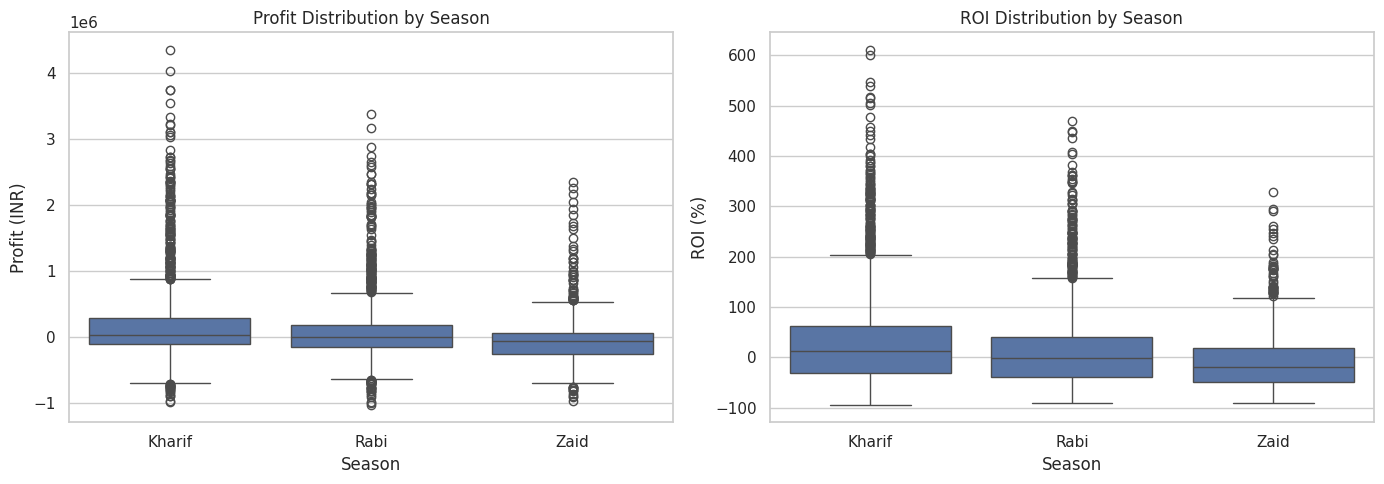

In [12]:
economic = data.groupby("Season")[
    ["Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR",
     "Profit_INR", "Profit_Margin_pct", "ROI_pct"]
].mean().round(2)

display(economic)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=data, x="Season", y="Profit_INR", ax=axes[0])
axes[0].set_title("Profit Distribution by Season")
axes[0].set_ylabel("Profit (INR)")

sns.boxplot(data=data, x="Season", y="ROI_pct", ax=axes[1])
axes[1].set_title("ROI Distribution by Season")
axes[1].set_ylabel("ROI (%)")

plt.tight_layout()
plt.show()


## 13. Crop-wise and Season-wise Comparison

Avg_Yield   Avg_Profit  Avg_Water_Efficiency  Farms
Season Crop                                                          
Kharif Sugarcane      53.46 1,000,790.81                 36.00    125
       Chilli          1.73   954,380.42                  3.26    185
       Cotton          1.37   216,999.55                  2.13    215
       Groundnut       1.48   108,265.44                  3.58    193
       Pulses          1.04    43,338.90                  3.35    221
       Maize           2.97   -39,332.67                  6.05    234
       Rice            2.71   -64,903.40                  2.17    314
       Wheat           2.26  -105,871.87                  4.76    292
Rabi   Sugarcane      43.94   731,612.86                 27.92    129
       Chilli          1.46   638,572.50                  2.89    163
       Cotton          1.19   107,343.59                  1.94    201
       Groundnut       1.22    10,416.54                  2.90    177
       Pulses          0.87   -14,309.14                  2.70    213
       Maize           2.61   -89,133.40                  5.46    233
       Rice            2.33   -98,427.87                  1.84    274
       Wheat           2.06  -119,954.57                  4.69    237
Zaid   Sugarcane      38.42   583,635.80                 23.39     51
       Chilli          1.18   448,659.09                  2.20     64
       Cotton          0.95   -53,925.34                  1.49     92
       Groundnut       1.04   -68,872.50                  2.47     54
       Pulses          0.65  -139,227.81                  1.95     62
       Wheat           1.75  -193,208.95                  4.02     85
       Maize           2.30  -194,049.17                  4.75     84
       Rice            1.90  -227,239.34                  1.53    102

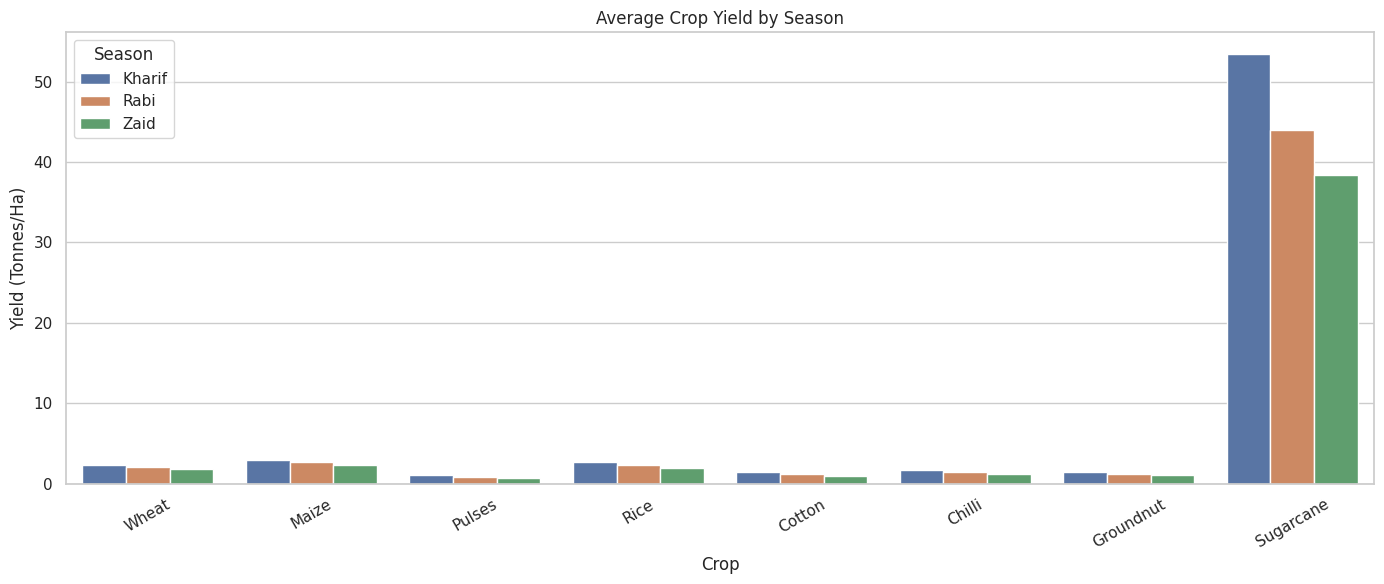

In [13]:
crop_season = data.groupby(["Season", "Crop"]).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Farms=("Farm_ID", "count")
).round(2)

display(crop_season.sort_values(["Season", "Avg_Profit"], ascending=[True, False]))

plt.figure(figsize=(14, 6))
sns.barplot(data=data, x="Crop", y="Yield_Tonnes_Ha", hue="Season",
            estimator="mean", errorbar=None)
plt.title("Average Crop Yield by Season")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 14. State-wise Seasonal Consistency

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.69,3.49,4.48
Gujarat,6.34,5.52,4.10
Karnataka,6.52,4.61,6.62
Madhya Pradesh,6.00,3.80,5.54
Maharashtra,5.45,5.50,2.29
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.56,4.10
Telangana,5.57,4.83,4.28


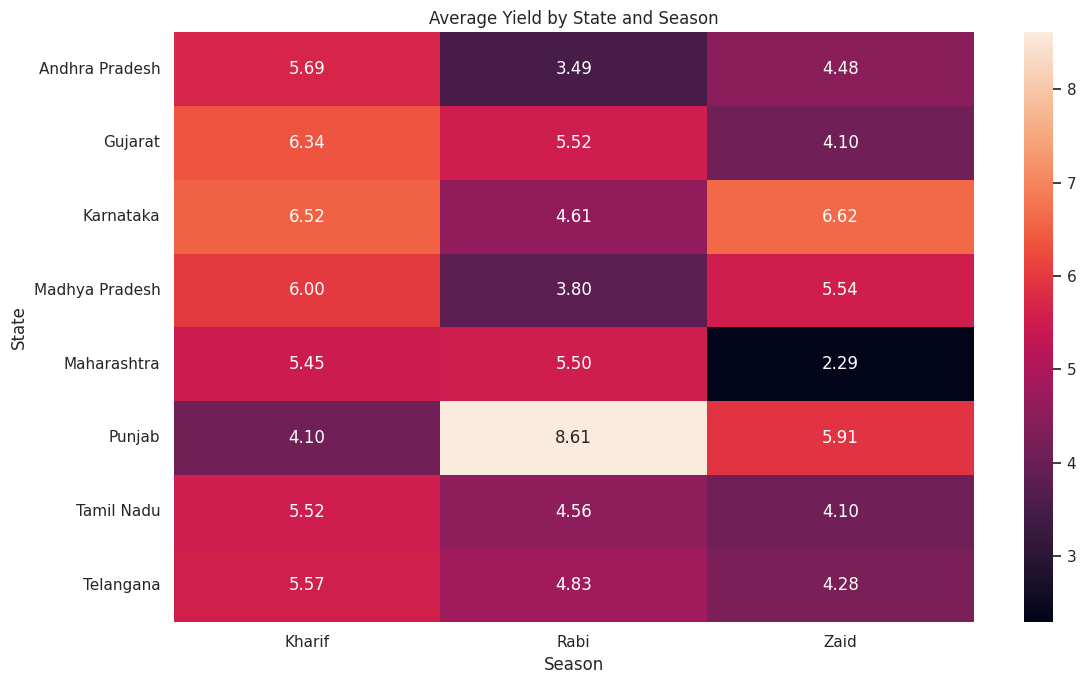

In [14]:
state_season = data.pivot_table(
    index="State",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
).round(2)

display(state_season)

plt.figure(figsize=(12, 7))
sns.heatmap(state_season, annot=True, fmt=".2f")
plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 15. Irrigation Method Analysis

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


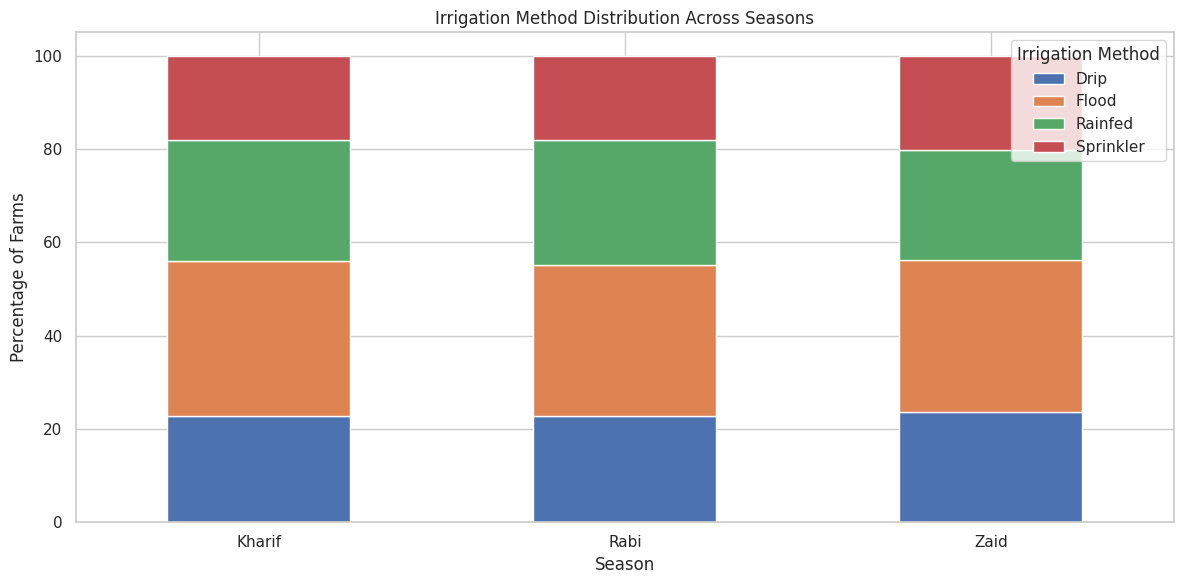

In [15]:
irrigation_counts = pd.crosstab(data["Season"], data["Irrigation_Method"])
display(irrigation_counts)

irrigation_pct = pd.crosstab(
    data["Season"], data["Irrigation_Method"], normalize="index"
).mul(100).round(2)

display(irrigation_pct)

irrigation_pct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Irrigation Method Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Percentage of Farms")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method")
plt.tight_layout()
plt.show()


## 16. Relationship Between Environmental/Resource Factors and Yield

Pearson correlation is used for continuous variables. It measures linear association, not causation.

Yield rows with missing yield values are excluded from this section.


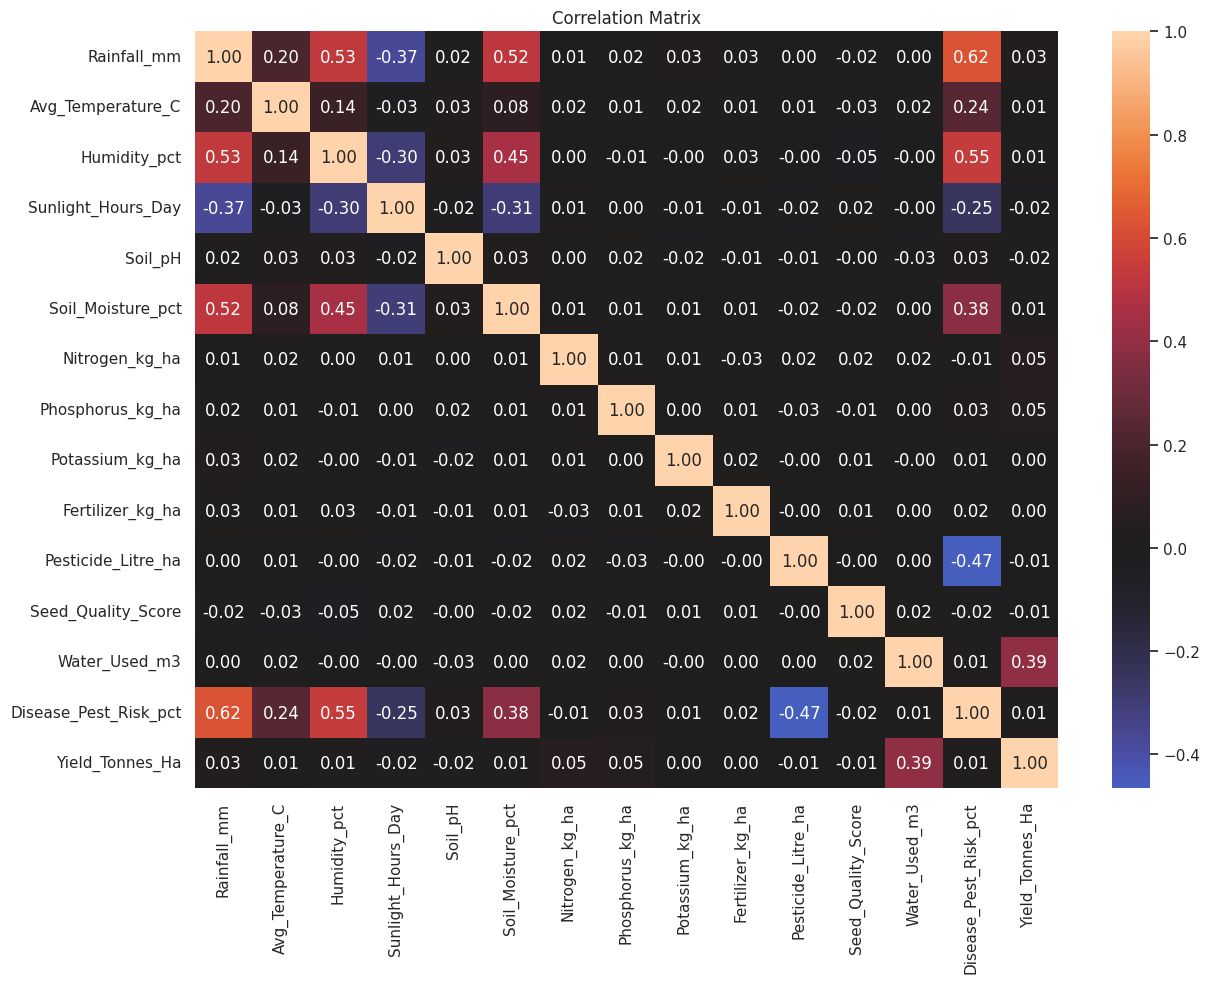

,Correlation with Yield
Soil_pH,-0.02
Sunlight_Hours_Day,-0.02
Pesticide_Litre_ha,-0.01
Seed_Quality_Score,-0.01
Fertilizer_kg_ha,0.00
Potassium_kg_ha,0.00
Avg_Temperature_C,0.01
Soil_Moisture_pct,0.01
Humidity_pct,0.01
Disease_Pest_Risk_pct,0.01


In [16]:
yield_data = data.dropna(subset=["Yield_Tonnes_Ha"]).copy()

corr_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Water_Used_m3",
    "Disease_Pest_Risk_pct", "Yield_Tonnes_Ha"
]

corr = yield_data[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

yield_corr = corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values()
display(yield_corr.to_frame("Correlation with Yield"))


## 17. Statistical Test: Does Yield Differ Across Seasons?

In [17]:
groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in yield_data.groupby("Season")
]

# One-way ANOVA
anova_stat, anova_p = stats.f_oneway(*groups)

print(f"One-way ANOVA statistic: {anova_stat:.4f}")
print(f"ANOVA p-value: {anova_p:.6f}")

if anova_p < 0.05:
    print("Result: The mean yield differs significantly across at least one pair of seasons (p < 0.05).")
else:
    print("Result: No statistically significant difference in mean yield was detected across seasons (p >= 0.05).")

# Kruskal-Wallis as a non-parametric check
kw_stat, kw_p = stats.kruskal(*groups)

print(f"\nKruskal-Wallis statistic: {kw_stat:.4f}")
print(f"Kruskal-Wallis p-value: {kw_p:.6f}")

if kw_p < 0.05:
    print("Non-parametric result: seasonal yield distributions differ significantly (p < 0.05).")
else:
    print("Non-parametric result: no significant difference was detected (p >= 0.05).")


One-way ANOVA statistic: 1.4580
ANOVA p-value: 0.232835
Result: No statistically significant difference in mean yield was detected across seasons (p >= 0.05).

Kruskal-Wallis statistic: 68.6043
Kruskal-Wallis p-value: 0.000000
Non-parametric result: seasonal yield distributions differ significantly (p < 0.05).


## 18. Statistical Test: Does Irrigation Choice Vary by Season?

In [18]:
contingency = pd.crosstab(data["Season"], data["Irrigation_Method"])

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("Result: Irrigation method and season are statistically associated (p < 0.05).")
else:
    print("Result: No statistically significant association between irrigation method and season was detected (p >= 0.05).")


Chi-square statistic: 3.5127
Degrees of freedom: 6
p-value: 0.742283
Result: No statistically significant association between irrigation method and season was detected (p >= 0.05).


## 19. Outlier Analysis

,Variable,Outlier_Count,Lower_Bound,Upper_Bound
0,Yield_Tonnes_Ha,302,-1.63,5.52
1,Profit_INR,404,"-696,111.00","763,567.00"
2,Water_Used_m3,276,"-6,072.75","16,171.25"
3,Water_Efficiency_t_per_1000m3,322,-3.57,10.38
4,Disease_Pest_Risk_pct,10,10.90,81.30


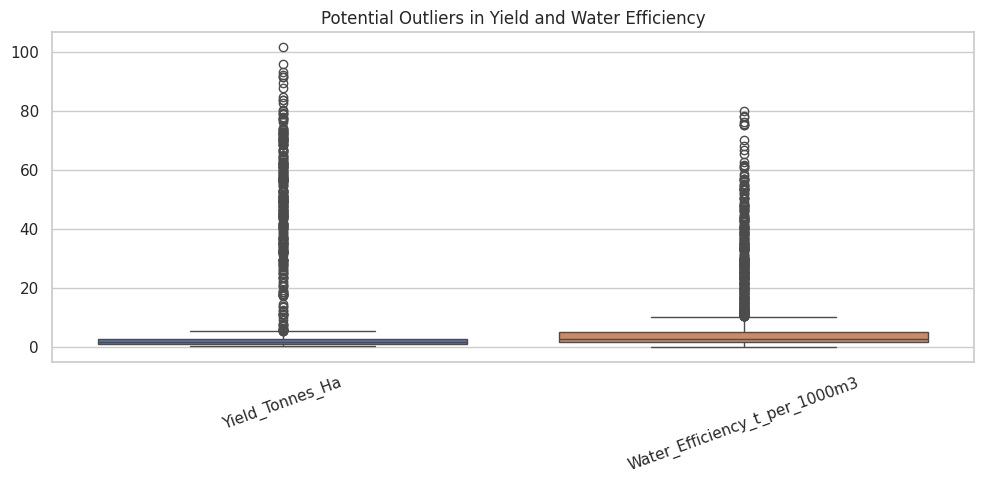

In [19]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

outlier_results = []

for col in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3",
            "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"]:
    count, lower, upper = iqr_outliers(data[col].dropna())
    outlier_results.append([col, count, lower, upper])

outlier_table = pd.DataFrame(
    outlier_results,
    columns=["Variable", "Outlier_Count", "Lower_Bound", "Upper_Bound"]
)

display(outlier_table)

plt.figure(figsize=(10, 5))
sns.boxplot(data=data[["Yield_Tonnes_Ha", "Water_Efficiency_t_per_1000m3"]])
plt.title("Potential Outliers in Yield and Water Efficiency")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 20. Identify the Best and Weakest Seasonal Performance

In [20]:
best_profit_season = season_summary["Avg_Profit_INR"].idxmax()
worst_profit_season = season_summary["Avg_Profit_INR"].idxmin()

best_yield_season = season_summary["Avg_Yield_T_per_Ha"].idxmax()
best_water_season = season_summary["Avg_Water_Efficiency"].idxmax()
lowest_risk_season = season_summary["Avg_Disease_Risk_pct"].idxmin()

print("Highest average profit:", best_profit_season)
print("Lowest average profit:", worst_profit_season)
print("Highest average yield:", best_yield_season)
print("Highest average water efficiency:", best_water_season)
print("Lowest average disease/pest risk:", lowest_risk_season)


Highest average profit: Kharif
Lowest average profit: Zaid
Highest average yield: Kharif
Highest average water efficiency: Kharif
Lowest average disease/pest risk: Zaid


## 21. Automatic Evidence-Based Findings

The following cell converts the calculated results into concise observations. These statements are based on the dataset rather than assumptions.


In [21]:
print("KEY FINDINGS")
print("-" * 70)

for season in season_summary.index:
    row = season_summary.loc[season]
    print(
        f"{season}: average yield = {row['Avg_Yield_T_per_Ha']:.2f} t/ha, "
        f"average profit = INR {row['Avg_Profit_INR']:,.0f}, "
        f"water efficiency = {row['Avg_Water_Efficiency']:.2f} t/1000m³."
    )

print(f"\nHighest average yield is observed in {best_yield_season}.")
print(f"Highest average profit is observed in {best_profit_season}.")
print(f"Highest average water efficiency is observed in {best_water_season}.")
print(f"Lowest average disease/pest risk is observed in {lowest_risk_season}.")

strongest_positive = yield_corr.idxmax()
strongest_negative = yield_corr.idxmin()

print(
    f"\nAmong the selected continuous variables, the strongest positive "
    f"linear correlation with yield is {strongest_positive} "
    f"({yield_corr.max():.2f})."
)
print(
    f"The strongest negative linear correlation with yield is {strongest_negative} "
    f"({yield_corr.min():.2f})."
)


KEY FINDINGS
----------------------------------------------------------------------
Kharif: average yield = 5.64 t/ha, average profit = INR 178,915, water efficiency = 5.89 t/1000m³.
Rabi: average yield = 5.08 t/ha, average profit = INR 87,689, water efficiency = 5.19 t/1000m³.
Zaid: average yield = 4.67 t/ha, average profit = INR -24,805, water efficiency = 4.41 t/1000m³.

Highest average yield is observed in Kharif.
Highest average profit is observed in Kharif.
Highest average water efficiency is observed in Kharif.
Lowest average disease/pest risk is observed in Zaid.

Among the selected continuous variables, the strongest positive linear correlation with yield is Water_Used_m3 (0.39).
The strongest negative linear correlation with yield is Soil_pH (-0.02).


## 22. Data-Driven Recommendations

Use the following principles when interpreting the results:

1. **Season-specific planning:** Use the seasonal performance table to prioritize practices associated with stronger yield and profitability.
2. **Water management:** Compare water efficiency rather than water use alone. High water consumption is not automatically better if output per unit of water is low.
3. **Resource optimization:** Review fertilizer and pesticide use alongside yield and profit to identify potentially inefficient resource use.
4. **Environmental monitoring:** Track rainfall, temperature, humidity, soil moisture, and disease/pest risk because their seasonal distributions may explain part of the observed variation.
5. **Regional planning:** Seasonal averages should be checked against the state-level heatmap because a pattern at the national dataset level may not hold equally in every state.
6. **Investigate outliers:** Very high or low yield, profit, or water-efficiency observations should be investigated before making operational decisions.
7. **Avoid causal overclaiming:** Statistical association is evidence for further investigation, not proof that one factor directly caused a change in agricultural performance.


# 23. Final Conclusion

This analysis evaluates agricultural performance across **Kharif, Rabi, and Zaid** seasons using environmental, resource, production, water-use, and economic indicators.

The final conclusion should be written after running all cells and reviewing the calculated seasonal differences, statistical tests, correlations, state-level patterns, and outliers. The analysis is designed to answer not only **which season performs better**, but also **how and where performance differs and which associated factors deserve further investigation**.

### Project Deliverables
- Cleaned and prepared dataset
- Exploratory analysis
- Seasonal comparisons
- Environmental and resource analysis
- Economic performance analysis
- Crop and state comparisons
- Correlation analysis
- Statistical hypothesis testing
- Outlier analysis
- Evidence-based findings
- Data-driven recommendations

**End of Major Project**
